In [1]:
#数据增强已经完成
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# 数据增强函数
def augment_minority_data(data):
    augmented_data = data.copy()
    for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
        if col in augmented_data.columns:
            # 原有乘法增强
            augmented_data[col] *= np.random.uniform(0.9, 1.1)
            # 添加高斯噪声
            augmented_data[col] += np.random.normal(0, 0.05 * augmented_data[col].std(), size=len(augmented_data[col]))
    return augmented_data


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['expert-1']))


def augment_data_in_folder(folder_path, output_folder, labels_dict, num_augmented=5, minority_classes=[]):
    os.makedirs(output_folder, exist_ok=True)
    augmented_labels = {}

    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)

            try:
                data = pd.read_csv(file_path, encoding='ISO-8859-1')
            except UnicodeDecodeError as e:
                print(f"Error reading {file_name}: {e}")
                continue

            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)
            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            augmented_labels[base_name] = label

            if label in minority_classes:
                for i in range(num_augmented):
                    augmented_data = augment_minority_data(data)
                    augmented_file_name = f"{base_name}_augmented_{i+1}.csv"
                    augmented_output_path = os.path.join(output_folder, augmented_file_name)
                    augmented_data.to_csv(augmented_output_path, index=False)

                    augmented_labels[f"{base_name}_augmented_{i+1}"] = label

    labels_output_path = os.path.join(output_folder, "augmented_labels.xlsx")
    pd.DataFrame(list(augmented_labels.items()), columns=["filename", "label"]).to_excel(labels_output_path, index=False)
    
    # 计算增强后的标注统计
    label_counts = Counter(augmented_labels.values())
    print("Augmented label counts:")
    for label, count in label_counts.items():
        print(f"Label {label}: {count}")
    
    return augmented_labels


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx]

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            label_file = f"{geometry_folder}_{trail_name}_expert_labels_bo_modified.xlsx"
            labels_file_path = os.path.join(base_path, label_file)

            folder_path = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"Trial-{trail_names.index(trail_name) + 1}")
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")

            labels_dict = load_expert_labels(labels_file_path)

            label_counts = Counter(labels_dict.values())
            mean_count = np.mean(list(label_counts.values()))
            minority_classes = [label for label, count in label_counts.items() if count < mean_count]

            augmented_labels = augment_data_in_folder(folder_path, augmented_folder, labels_dict, num_augmented=5, minority_classes=minority_classes)

            features, labels = extract_features(augmented_folder, augmented_labels)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Augmented label counts:
Label 0: 231
Label 1: 210
Label 2: 186
Label 3: 54
Label 4: 42
Augmented label counts:
Label 0: 296
Label 1: 348
Label 2: 186
Label 3: 126
Label 4: 36
Augmented label counts:
Label 0: 149
Label 1: 49
Label 2: 66
Label 3: 84
Label 4: 42
Augmented label counts:
Label 0: 416
Label 1: 152
Label 2: 156
Label 3: 24
Label 4: 60
Augmented label counts:
Label 0: 664
Label 1: 358
Label 2: 1002
Label 3: 96
Label 4: 30
Augmented label counts:
Label 0: 222
Label 1: 161
Label 2: 113
Label 3: 84
Label 4: 54
Augmented label counts:
Label 0: 420
Label 1: 166
Label 2: 564
Label 3: 60
Label 4: 36
Augmented label counts:
Label 0: 293
Label 1: 195
Label 2: 816
Label 3: 42
Label 4: 72
Augmented label counts:
Label 0: 219
Label 1: 242
Label 2: 684
Label 3: 78
Label 4: 60
Augmented label counts:
Label 0: 170
Label 1: 130
Label 2: 140
Label 3: 222
Label 4: 30
Augmented label counts:
Label 0: 140
Label 1: 139
Label 2: 160
Label 3: 216
Label 4: 36
Augmented label counts:
Label 0: 228
Labe

ValueError: too many values to unpack (expected 2)

In [49]:
# 统计所有增强后的标注文件中的每种标注的总数量
def calculate_augmented_label_statistics(base_path, geometry_folders, trail_names):
    all_labels = []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_labels_file = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented", "augmented_labels.xlsx")
            if os.path.exists(augmented_labels_file):
                augmented_labels_df = pd.read_excel(augmented_labels_file)
                all_labels.extend(augmented_labels_df['label'].values)

    label_counts = Counter(all_labels)
    print("Augmented label statistics:")
    for label, count in label_counts.items():
        print(f"Label {label}: {count}")


def main_augmented_label_statistics():
    base_path = r'C:\Material-5083'
    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    calculate_augmented_label_statistics(base_path, geometry_folders, trail_names)


if __name__ == "__main__":
    main_augmented_label_statistics()


Augmented label statistics:
Label 5: 3980
Label 1: 3271
Label 2: 4619
Label 3: 1458
Label 4: 636


In [53]:
import os
import pandas as pd
from collections import Counter

# 主目录路径
base_path = r'C:\Material-5083'

# 动态生成标注文件路径的参数
geometry_folders = ['20', '60', '100', '120', '180']
trail_names = ['trail1', 'trail2', 'trail3']

# 定义函数：加载单个标注文件
def load_and_modify_labels(labels_file_path):
    # 加载标注文件
    expert_labels_df = pd.read_excel(labels_file_path)
    
    # 修改标注：将 0 修改为 5
    expert_labels_df['expert-1'] = expert_labels_df['expert-1'].replace(0, 5)
    
    # 保存修改后的文件
    expert_labels_df.to_excel(labels_file_path, index=False)
    print(f"文件已修改并保存: {labels_file_path}")

# 遍历目录并修改标注
def modify_labels(base_path, geometry_folders, trail_names):
    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            # 拼接标注文件路径
            label_file = f"{geometry_folder}_{trail_name}_expert_labels_bo_modified.xlsx"
            labels_file_path = os.path.join(base_path, label_file)

            # 检查文件是否存在
            if os.path.exists(labels_file_path):
                try:
                    # 加载并修改标注文件
                    load_and_modify_labels(labels_file_path)
                except Exception as e:
                    print(f"无法加载或修改文件 {labels_file_path}: {e}")
            else:
                print(f"文件不存在: {labels_file_path}")

# 执行修改
modify_labels(base_path, geometry_folders, trail_names)


文件已修改并保存: C:\Material-5083\20_trail1_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\20_trail2_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\20_trail3_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\60_trail1_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\60_trail2_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\60_trail3_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\100_trail1_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\100_trail2_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\100_trail3_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\120_trail1_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\120_trail2_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\120_trail3_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\180_trail1_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\180_trail2_expert_labels_bo_modified.xlsx
文件已修改并保存: C:\Material-5083\180_trail3_ex

In [55]:
import os
import pandas as pd
from collections import Counter

# 主目录路径
base_path = r'C:\Material-5083'

# 动态生成标注文件路径的参数
geometry_folders = ['20', '60', '100', '120', '180']
trail_names = ['trail1', 'trail2', 'trail3']

# 定义函数：加载单个标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    return expert_labels_df['expert-1'].tolist()

# 统计标注
def count_labels(base_path, geometry_folders, trail_names):
    label_counts = Counter()
    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            # 拼接标注文件路径
            label_file = f"{geometry_folder}_{trail_name}_expert_labels_bo_modified.xlsx"
            labels_file_path = os.path.join(base_path, label_file)

            # 检查文件是否存在
            if os.path.exists(labels_file_path):
                try:
                    # 加载文件中的标注数据
                    labels = load_expert_labels(labels_file_path)
                    # 更新计数
                    label_counts.update(labels)
                except Exception as e:
                    print(f"无法加载文件 {labels_file_path}: {e}")
            else:
                print(f"文件不存在: {labels_file_path}")
    
    return label_counts

# 执行统计
label_counts = count_labels(base_path, geometry_folders, trail_names)

# 输出统计结果
print("标注数量统计：")
for label, count in sorted(label_counts.items()):
    print(f"标注 {label}: {count} 个")

标注数量统计：
标注 1: 2456 个
标注 2: 1991 个
标注 3: 264 个
标注 4: 107 个
标注 5: 3980 个


Fold 1 Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.97      0.94       172
           2       0.84      0.97      0.90       610
           3       0.80      0.70      0.75       243
           4       1.00      0.36      0.53       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



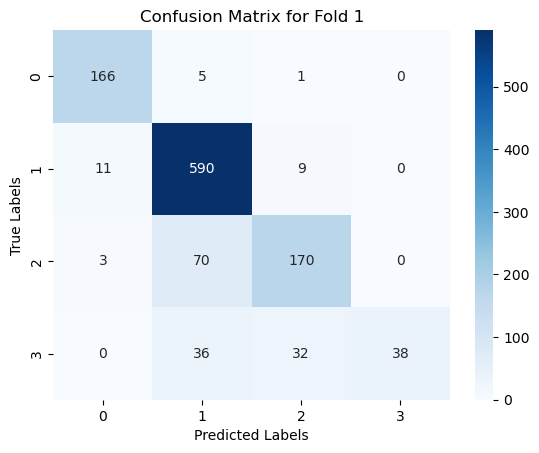

Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.93      0.92       172
           2       0.83      0.95      0.89       610
           3       0.79      0.67      0.73       243
           4       1.00      0.43      0.61       106

    accuracy                           0.84      1131
   macro avg       0.88      0.75      0.78      1131
weighted avg       0.85      0.84      0.83      1131



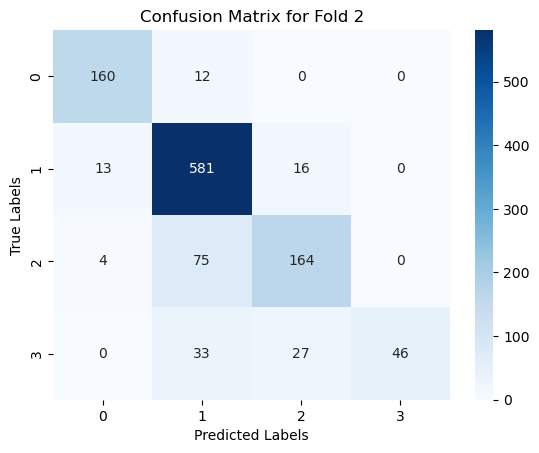

Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.96      0.93       172
           2       0.84      0.96      0.90       610
           3       0.85      0.72      0.78       243
           4       0.95      0.36      0.52       106

    accuracy                           0.85      1131
   macro avg       0.88      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



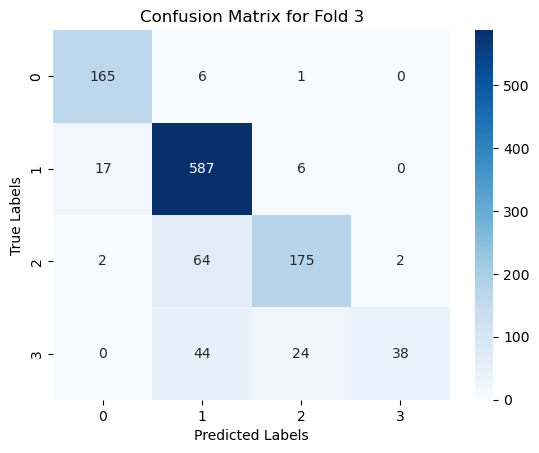

Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.94      0.90       172
           2       0.81      0.95      0.88       610
           3       0.82      0.65      0.73       243
           4       1.00      0.39      0.56       106

    accuracy                           0.83      1131
   macro avg       0.88      0.73      0.77      1131
weighted avg       0.84      0.83      0.82      1131



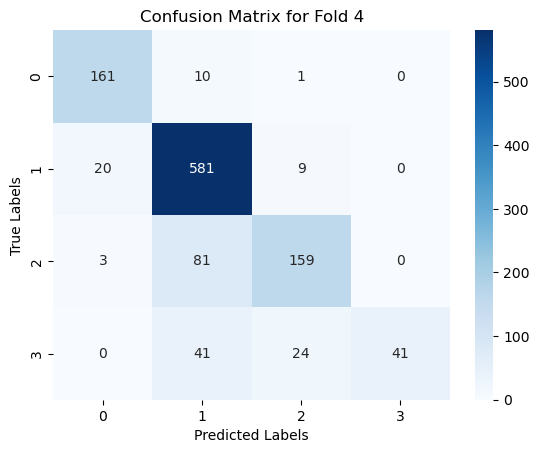

Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.95      0.92       172
           2       0.83      0.95      0.88       610
           3       0.78      0.68      0.73       243
           4       0.97      0.37      0.53       106

    accuracy                           0.84      1131
   macro avg       0.87      0.74      0.77      1131
weighted avg       0.84      0.84      0.82      1131



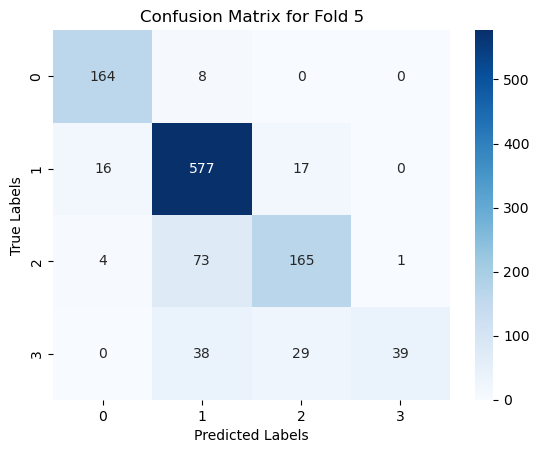

Cross-validation accuracy: [0.852343059239611, 0.8408488063660478, 0.8532272325375774, 0.8328912466843501, 0.8355437665782494]
Mean accuracy: 0.8429708222811672
Model saved as 'random_forest_model.pkl'


In [23]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Label distribution after SMOTE: [   0 3050 3050 3050 3050]
Fold 1 - Training label distribution: [   0 2440 2440 2440 2440]
Fold 1 - Test label distribution: [  0 610 610 610 610]
Fold 1 Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97       610
           2       0.88      0.89      0.88       610
           3       0.95      0.89      0.92       610
           4       0.98      0.98      0.98       610

    accuracy                           0.94      2440
   macro avg       0.94      0.94      0.94      2440
weighted avg       0.94      0.94      0.94      2440



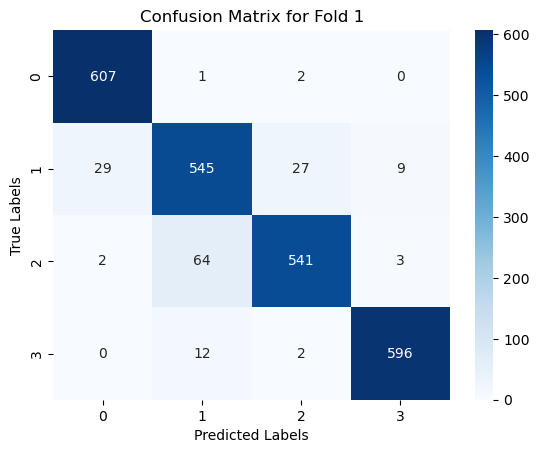

Fold 2 - Training label distribution: [   0 2440 2440 2440 2440]
Fold 2 - Test label distribution: [  0 610 610 610 610]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97       610
           2       0.87      0.90      0.89       610
           3       0.96      0.89      0.93       610
           4       0.99      0.97      0.98       610

    accuracy                           0.94      2440
   macro avg       0.94      0.94      0.94      2440
weighted avg       0.94      0.94      0.94      2440



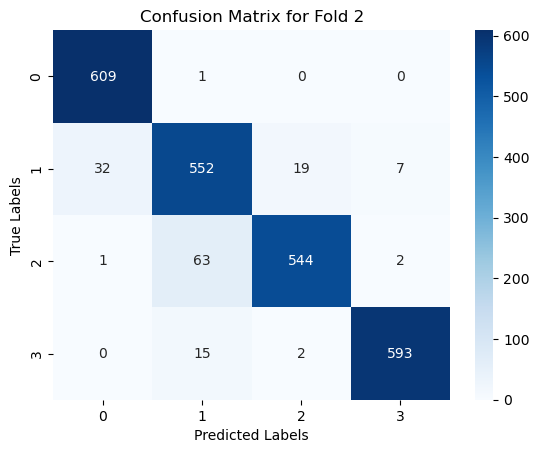

Fold 3 - Training label distribution: [   0 2440 2440 2440 2440]
Fold 3 - Test label distribution: [  0 610 610 610 610]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97       610
           2       0.90      0.92      0.91       610
           3       0.95      0.90      0.93       610
           4       0.99      0.98      0.99       610

    accuracy                           0.95      2440
   macro avg       0.95      0.95      0.95      2440
weighted avg       0.95      0.95      0.95      2440



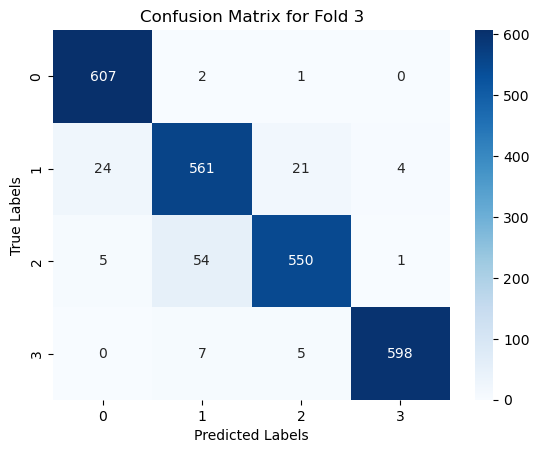

Fold 4 - Training label distribution: [   0 2440 2440 2440 2440]
Fold 4 - Test label distribution: [  0 610 610 610 610]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.99      0.97       610
           2       0.87      0.91      0.89       610
           3       0.96      0.87      0.91       610
           4       0.99      0.98      0.99       610

    accuracy                           0.94      2440
   macro avg       0.94      0.94      0.94      2440
weighted avg       0.94      0.94      0.94      2440



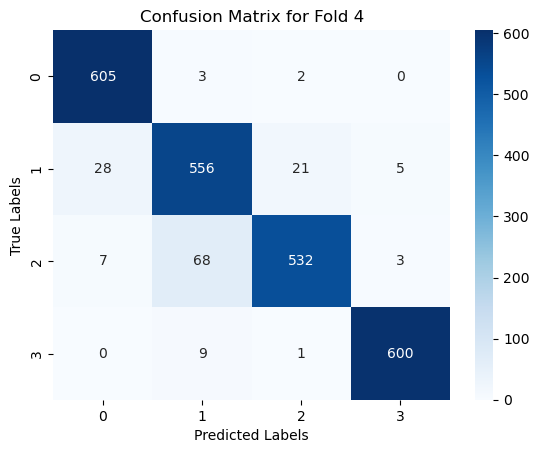

Fold 5 - Training label distribution: [   0 2440 2440 2440 2440]
Fold 5 - Test label distribution: [  0 610 610 610 610]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       610
           2       0.89      0.91      0.90       610
           3       0.95      0.90      0.92       610
           4       0.98      0.98      0.98       610

    accuracy                           0.95      2440
   macro avg       0.95      0.95      0.95      2440
weighted avg       0.95      0.95      0.95      2440



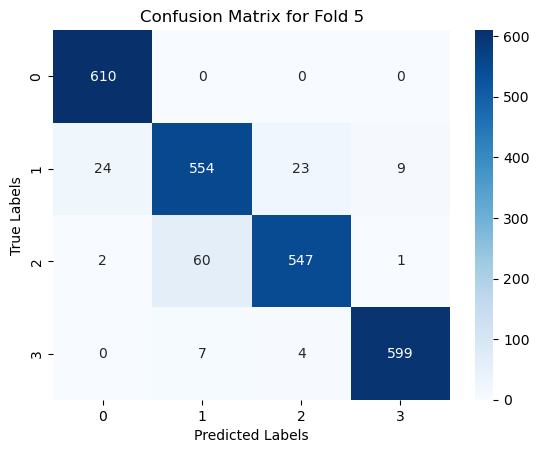

Cross-validation accuracy: [0.9381147540983606, 0.9418032786885245, 0.9491803278688524, 0.9397540983606557, 0.9467213114754098]
Mean accuracy: 0.9431147540983605
Model saved as 'random_forest_model.pkl'


In [45]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 使用 SMOTE 进行过采样，以确保每个类都有足够的样本数量
    smote = SMOTE(random_state=42)
    features, labels = smote.fit_resample(features, labels)

    # 打印采样后的标签分布，确保没有类别被遗漏
    print(f"Label distribution after SMOTE: {np.bincount(labels)}")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 2, 4: 5, 5: 1})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()

In [41]:
import os
import pandas as pd
from collections import Counter

# 修改标签并统计增强数据的标签信息
def calculate_and_update_augmented_label_statistics(base_path, geometry_folders, trail_names):
    all_labels = []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            # 定位增强标签文件
            augmented_labels_file = os.path.join(
                base_path,
                f"Geometry-{geometry_folder}mm",
                f"{trail_name}_augmented",
                "augmented_labels.xlsx"
            )
            if os.path.exists(augmented_labels_file):
                # 读取增强标签文件
                augmented_labels_df = pd.read_excel(augmented_labels_file)

                # 检查是否存在标签 0，并将其替换为标签 5
                if 0 in augmented_labels_df['label'].values:
                    augmented_labels_df['label'] = augmented_labels_df['label'].replace({0: 5})
                    
                    # 将修改后的 DataFrame 写回文件
                    augmented_labels_df.to_excel(augmented_labels_file, index=False)

                # 将修改后的标签添加到统计中
                all_labels.extend(augmented_labels_df['label'].values)

    # 统计标签数量
    label_counts = Counter(all_labels)
    print("Updated augmented label statistics:")
    for label, count in label_counts.items():
        print(f"Label {label}: {count}")

# 主函数
def main_augmented_label_statistics():
    base_path = r'C:\Material-5083'
    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    calculate_and_update_augmented_label_statistics(base_path, geometry_folders, trail_names)

if __name__ == "__main__":
    main_augmented_label_statistics()


Updated augmented label statistics:
Label 5: 3980
Label 1: 3271
Label 2: 4619
Label 3: 1458
Label 4: 636


Label distribution before training: [   0  860 3050 1215  530]
Fold 1 - Training label distribution: [   0  688 2440  972  424]
Fold 1 - Test label distribution: [  0 172 610 243 106]
Fold 1 Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       172
           2       0.85      0.97      0.90       610
           3       0.82      0.72      0.76       243
           4       0.98      0.42      0.59       106

    accuracy                           0.86      1131
   macro avg       0.90      0.77      0.80      1131
weighted avg       0.87      0.86      0.85      1131



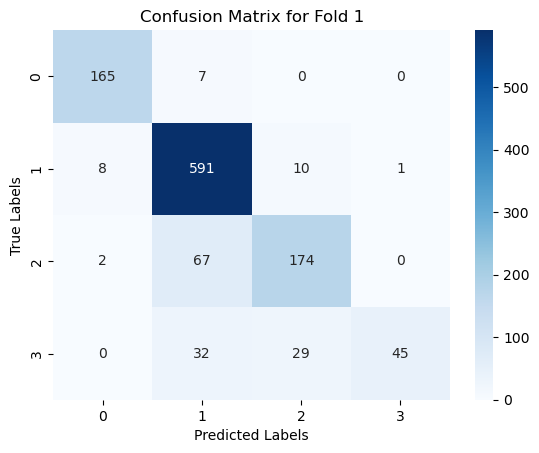

Fold 2 - Training label distribution: [   0  688 2440  972  424]
Fold 2 - Test label distribution: [  0 172 610 243 106]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.93      0.91       172
           2       0.83      0.95      0.88       610
           3       0.78      0.67      0.72       243
           4       0.98      0.43      0.60       106

    accuracy                           0.84      1131
   macro avg       0.87      0.75      0.78      1131
weighted avg       0.84      0.84      0.83      1131



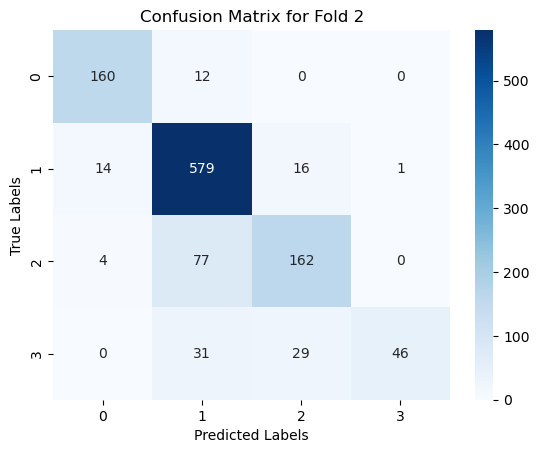

Fold 3 - Training label distribution: [   0  688 2440  972  424]
Fold 3 - Test label distribution: [  0 172 610 243 106]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.95      0.92       172
           2       0.83      0.96      0.89       610
           3       0.86      0.71      0.78       243
           4       1.00      0.39      0.56       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



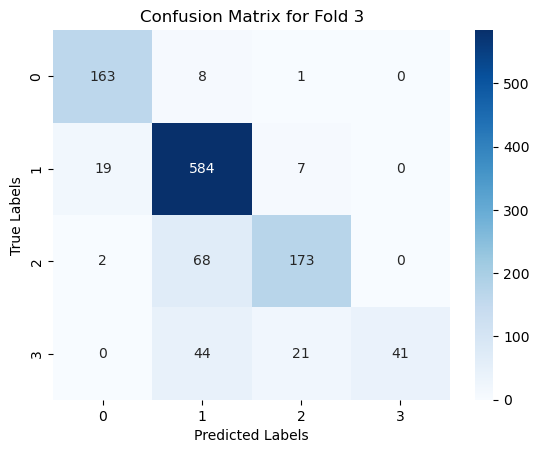

Fold 4 - Training label distribution: [   0  688 2440  972  424]
Fold 4 - Test label distribution: [  0 172 610 243 106]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.95      0.90       172
           2       0.82      0.95      0.88       610
           3       0.83      0.65      0.73       243
           4       0.98      0.42      0.58       106

    accuracy                           0.83      1131
   macro avg       0.87      0.74      0.77      1131
weighted avg       0.84      0.83      0.82      1131



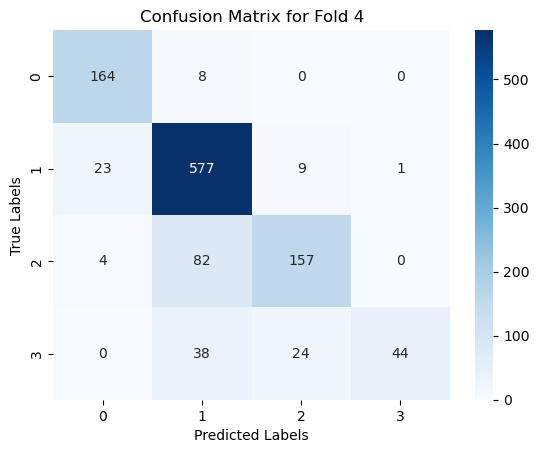

Fold 5 - Training label distribution: [   0  688 2440  972  424]
Fold 5 - Test label distribution: [  0 172 610 243 106]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.94      0.91       172
           2       0.82      0.95      0.88       610
           3       0.79      0.67      0.73       243
           4       1.00      0.35      0.52       106

    accuracy                           0.83      1131
   macro avg       0.87      0.73      0.76      1131
weighted avg       0.84      0.83      0.82      1131



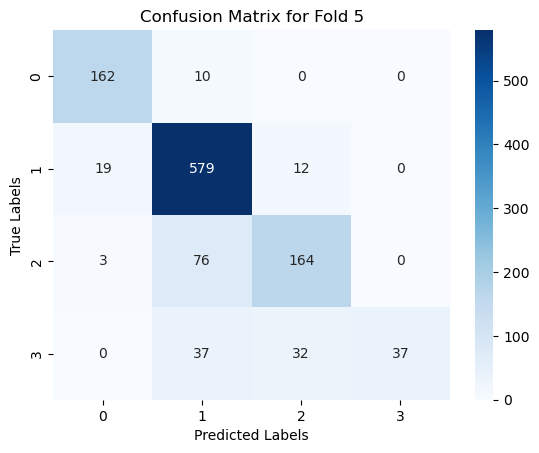

Cross-validation accuracy: [0.8620689655172413, 0.8373121131741822, 0.8496905393457118, 0.8328912466843501, 0.8328912466843501]
Mean accuracy: 0.8429708222811672
Model saved as 'random_forest_model.pkl'


In [47]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 2})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Label distribution before training: [   0  860 3050 1215  530]
Fold 1 - Training label distribution: [   0  688 2440  972  424]
Fold 1 - Test label distribution: [  0 172 610 243 106]
Fold 1 Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       172
           2       0.84      0.96      0.90       610
           3       0.79      0.70      0.74       243
           4       0.98      0.39      0.55       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.79      1131
weighted avg       0.86      0.85      0.84      1131



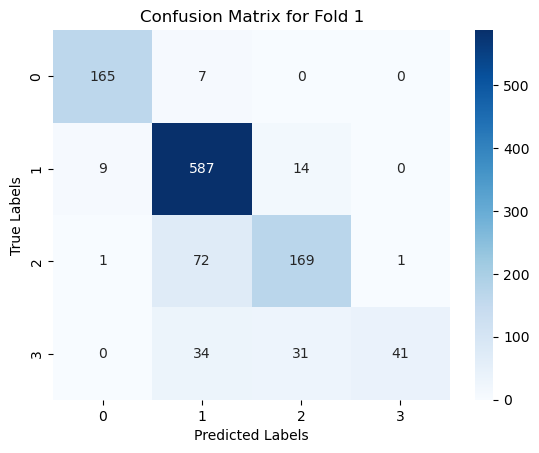

Fold 2 - Training label distribution: [   0  688 2440  972  424]
Fold 2 - Test label distribution: [  0 172 610 243 106]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.94      0.93       172
           2       0.84      0.95      0.89       610
           3       0.79      0.68      0.73       243
           4       1.00      0.48      0.65       106

    accuracy                           0.85      1131
   macro avg       0.88      0.76      0.80      1131
weighted avg       0.85      0.85      0.84      1131



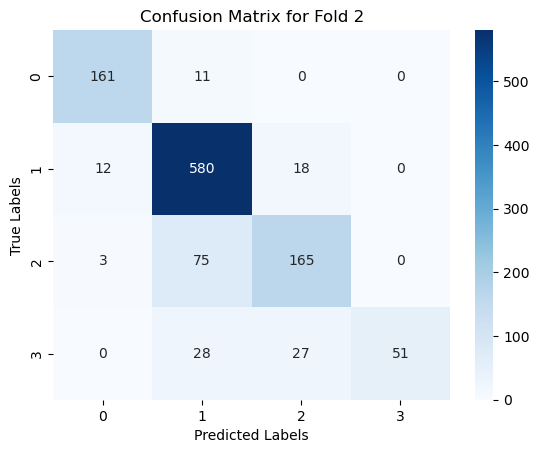

Fold 3 - Training label distribution: [   0  688 2440  972  424]
Fold 3 - Test label distribution: [  0 172 610 243 106]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.96      0.92       172
           2       0.83      0.96      0.89       610
           3       0.84      0.72      0.78       243
           4       1.00      0.36      0.53       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



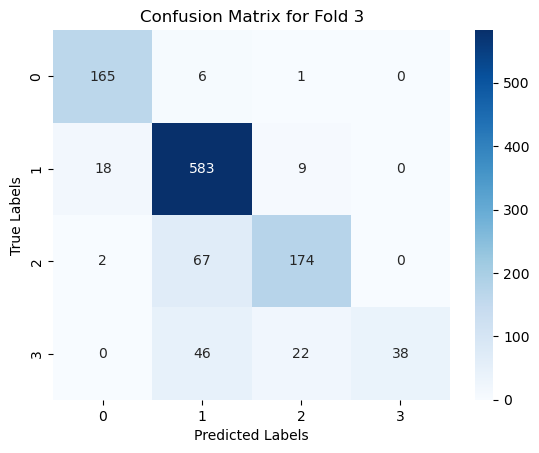

Fold 4 - Training label distribution: [   0  688 2440  972  424]
Fold 4 - Test label distribution: [  0 172 610 243 106]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.95      0.91       172
           2       0.82      0.95      0.88       610
           3       0.82      0.65      0.72       243
           4       1.00      0.40      0.57       106

    accuracy                           0.83      1131
   macro avg       0.88      0.74      0.77      1131
weighted avg       0.84      0.83      0.82      1131



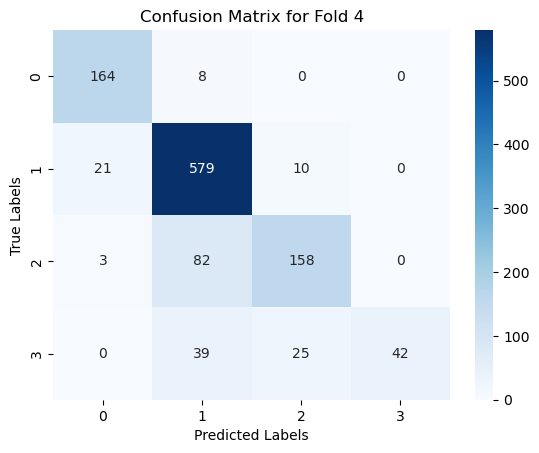

Fold 5 - Training label distribution: [   0  688 2440  972  424]
Fold 5 - Test label distribution: [  0 172 610 243 106]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.95      0.92       172
           2       0.84      0.95      0.89       610
           3       0.78      0.70      0.74       243
           4       0.97      0.35      0.51       106

    accuracy                           0.84      1131
   macro avg       0.87      0.74      0.77      1131
weighted avg       0.85      0.84      0.83      1131



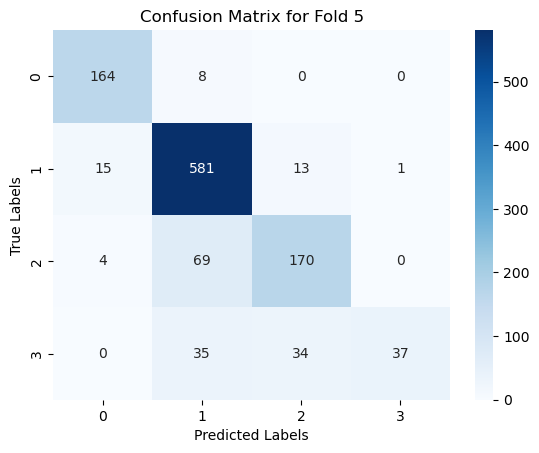

Cross-validation accuracy: [0.8505747126436781, 0.8461538461538461, 0.8488063660477454, 0.8337754199823165, 0.8417329796640142]
Mean accuracy: 0.8442086648983201
Model saved as 'random_forest_model.pkl'


In [57]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 2})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Loaded labels:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Loaded labels:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Loaded labels:
label
5    149
3     84
2     66
1     49
4     42
Name: count, dtype: int64
Loaded labels:
label
5    416
2    156
1    152
4     60
3     24
Name: count, dtype: int64
Loaded labels:
label
2    1002
5     664
1     358
3      96
4      30
Name: count, dtype: int64
Loaded labels:
label
5    222
1    161
2    113
3     84
4     54
Name: count, dtype: int64
Loaded labels:
label
2    564
5    420
1    166
3     60
4     36
Name: count, dtype: int64
Loaded labels:
label
2    816
5    293
1    195
4     72
3     42
Name: count, dtype: int64
Loaded labels:
label
2    684
1    242
5    219
3     78
4     60
Name: count, dtype: int64
Loaded labels:
label
3    222
5    170
2    140
1    130
4     30
Name: count, dtype: int64
Loaded labels:
label
3    216
2    160
5    140
1    139
4     36
Name: cou

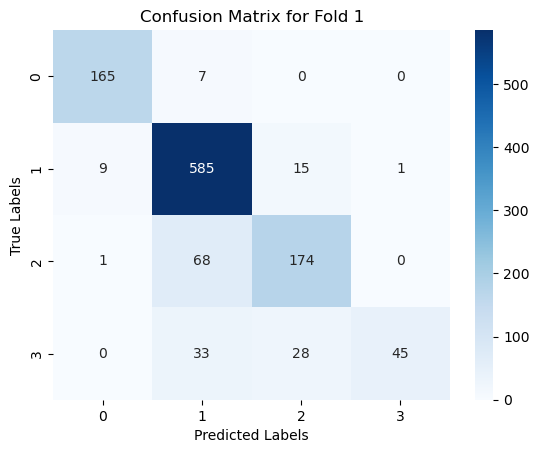

Fold 2 - Training label distribution: [   0  688 2440  972  424]
Fold 2 - Test label distribution: [  0 172 610 243 106]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92       172
           2       0.82      0.96      0.89       610
           3       0.79      0.65      0.72       243
           4       1.00      0.44      0.61       106

    accuracy                           0.84      1131
   macro avg       0.88      0.74      0.78      1131
weighted avg       0.85      0.84      0.83      1131



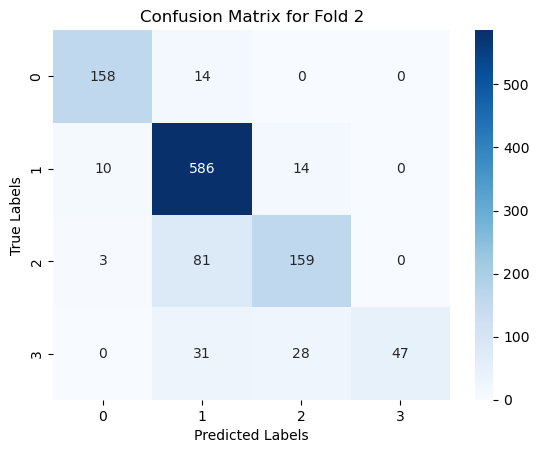

Fold 3 - Training label distribution: [   0  688 2440  972  424]
Fold 3 - Test label distribution: [  0 172 610 243 106]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.94      0.91       172
           2       0.83      0.96      0.89       610
           3       0.85      0.71      0.78       243
           4       0.98      0.38      0.54       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



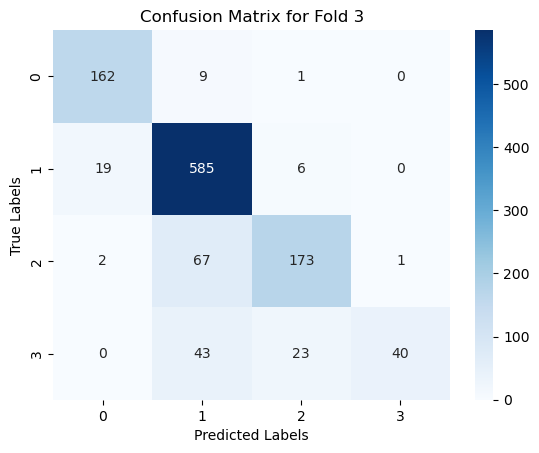

Fold 4 - Training label distribution: [   0  688 2440  972  424]
Fold 4 - Test label distribution: [  0 172 610 243 106]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.97      0.91       172
           2       0.82      0.94      0.88       610
           3       0.82      0.65      0.73       243
           4       0.95      0.38      0.54       106

    accuracy                           0.83      1131
   macro avg       0.86      0.73      0.76      1131
weighted avg       0.84      0.83      0.82      1131



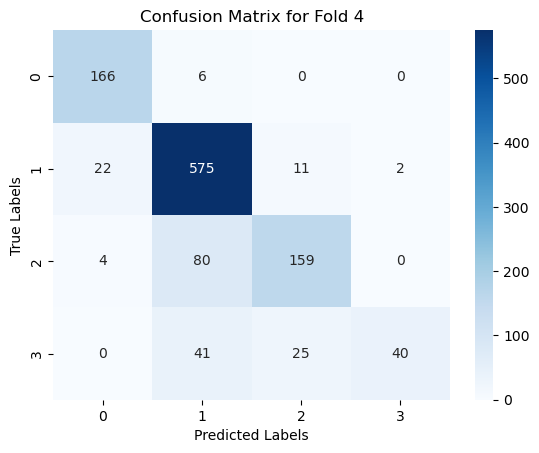

Fold 5 - Training label distribution: [   0  688 2440  972  424]
Fold 5 - Test label distribution: [  0 172 610 243 106]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.95      0.93       172
           2       0.83      0.96      0.89       610
           3       0.79      0.68      0.73       243
           4       1.00      0.36      0.53       106

    accuracy                           0.84      1131
   macro avg       0.88      0.74      0.77      1131
weighted avg       0.85      0.84      0.83      1131



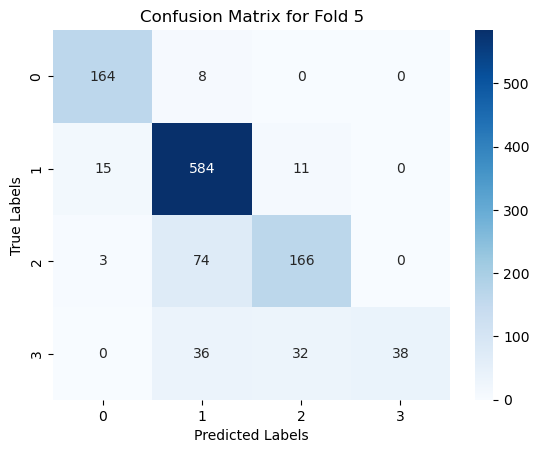

Cross-validation accuracy: [0.8567639257294429, 0.8399646330680813, 0.8488063660477454, 0.8311229000884174, 0.8417329796640142]
Mean accuracy: 0.8436781609195402
Model saved as 'random_forest_model.pkl'


In [59]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型
    labels = labels.astype(int)

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 2})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Loaded labels:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Loaded labels:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Loaded labels:
label
5    149
3     84
2     66
1     49
4     42
Name: count, dtype: int64
Loaded labels:
label
5    416
2    156
1    152
4     60
3     24
Name: count, dtype: int64
Loaded labels:
label
2    1002
5     664
1     358
3      96
4      30
Name: count, dtype: int64
Loaded labels:
label
5    222
1    161
2    113
3     84
4     54
Name: count, dtype: int64
Loaded labels:
label
2    564
5    420
1    166
3     60
4     36
Name: count, dtype: int64
Loaded labels:
label
2    816
5    293
1    195
4     72
3     42
Name: count, dtype: int64
Loaded labels:
label
2    684
1    242
5    219
3     78
4     60
Name: count, dtype: int64
Loaded labels:
label
3    222
5    170
2    140
1    130
4     30
Name: count, dtype: int64
Loaded labels:
label
3    216
2    160
5    140
1    139
4     36
Name: cou

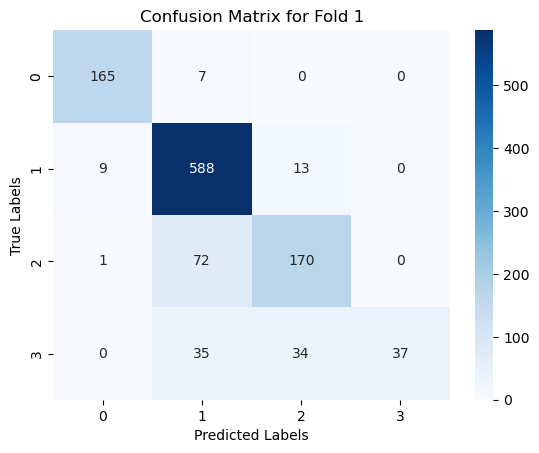

Fold 2 - Training label distribution: [   0  688 2440  972  424]
Fold 2 - Test label distribution: [  0 172 610 243 106]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.94      0.92       172
           2       0.83      0.95      0.89       610
           3       0.80      0.67      0.73       243
           4       0.94      0.44      0.60       106

    accuracy                           0.84      1131
   macro avg       0.87      0.75      0.78      1131
weighted avg       0.84      0.84      0.83      1131



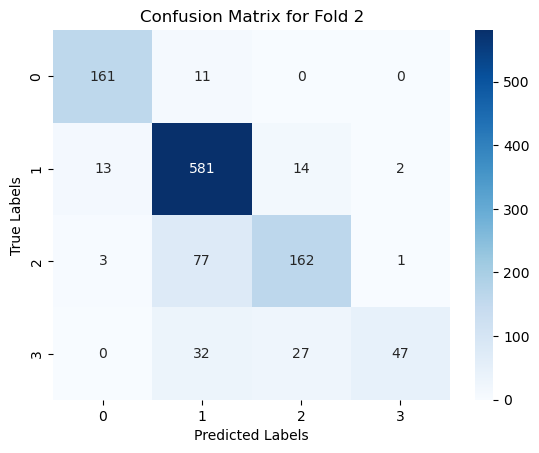

Fold 3 - Training label distribution: [   0  688 2440  972  424]
Fold 3 - Test label distribution: [  0 172 610 243 106]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.96      0.92       172
           2       0.83      0.95      0.89       610
           3       0.84      0.73      0.78       243
           4       1.00      0.35      0.52       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



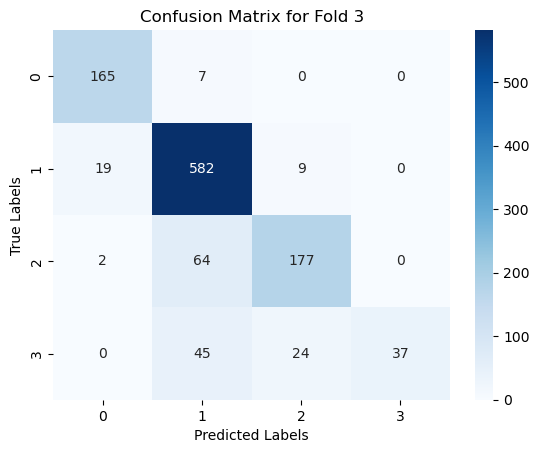

Fold 4 - Training label distribution: [   0  688 2440  972  424]
Fold 4 - Test label distribution: [  0 172 610 243 106]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.97      0.92       172
           2       0.81      0.95      0.88       610
           3       0.81      0.64      0.72       243
           4       0.95      0.36      0.52       106

    accuracy                           0.83      1131
   macro avg       0.86      0.73      0.76      1131
weighted avg       0.84      0.83      0.81      1131



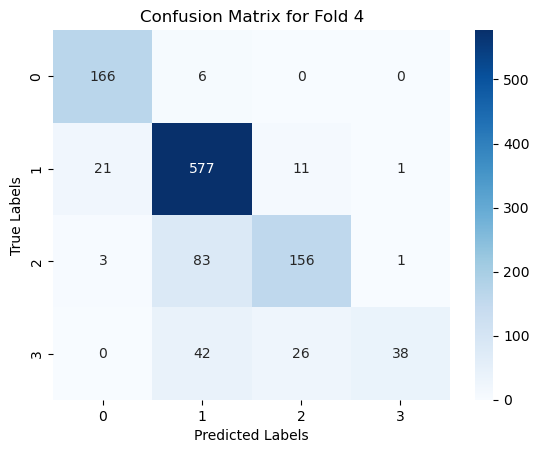

Fold 5 - Training label distribution: [   0  688 2440  972  424]
Fold 5 - Test label distribution: [  0 172 610 243 106]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.97      0.94       172
           2       0.84      0.96      0.89       610
           3       0.80      0.68      0.73       243
           4       0.95      0.37      0.53       106

    accuracy                           0.84      1131
   macro avg       0.87      0.74      0.77      1131
weighted avg       0.85      0.84      0.83      1131



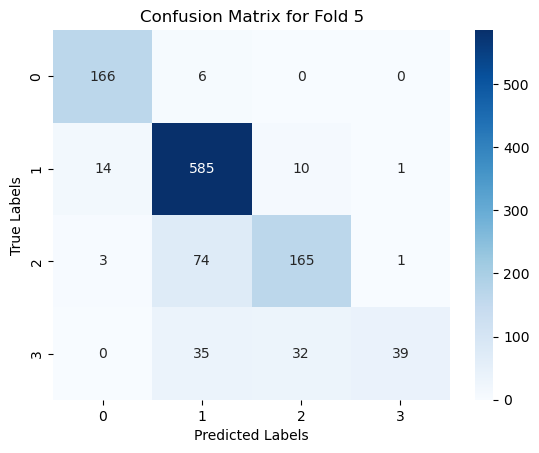

Cross-validation accuracy: [0.8488063660477454, 0.8408488063660478, 0.8496905393457118, 0.8284703801945181, 0.8443854995579133]
Mean accuracy: 0.8424403183023873
Model saved as 'random_forest_model.pkl'


In [61]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型，并移除类别 0
    labels = labels.astype(int)
    unique_labels = np.unique(labels)
    print(f"Unique labels after processing: {unique_labels}")  # 打印唯一标签，确保没有类别 0

    if 0 in unique_labels:
        raise ValueError("Label 0 is still present in the dataset. Please check the label processing.")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 2})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        conf_matrix = confusion_matrix(test_labels, test_predictions)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()

Loaded labels:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Loaded labels:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Loaded labels:
label
5    149
3     84
2     66
1     49
4     42
Name: count, dtype: int64
Loaded labels:
label
5    416
2    156
1    152
4     60
3     24
Name: count, dtype: int64
Loaded labels:
label
2    1002
5     664
1     358
3      96
4      30
Name: count, dtype: int64
Loaded labels:
label
5    222
1    161
2    113
3     84
4     54
Name: count, dtype: int64
Loaded labels:
label
2    564
5    420
1    166
3     60
4     36
Name: count, dtype: int64
Loaded labels:
label
2    816
5    293
1    195
4     72
3     42
Name: count, dtype: int64
Loaded labels:
label
2    684
1    242
5    219
3     78
4     60
Name: count, dtype: int64
Loaded labels:
label
3    222
5    170
2    140
1    130
4     30
Name: count, dtype: int64
Loaded labels:
label
3    216
2    160
5    140
1    139
4     36
Name: cou

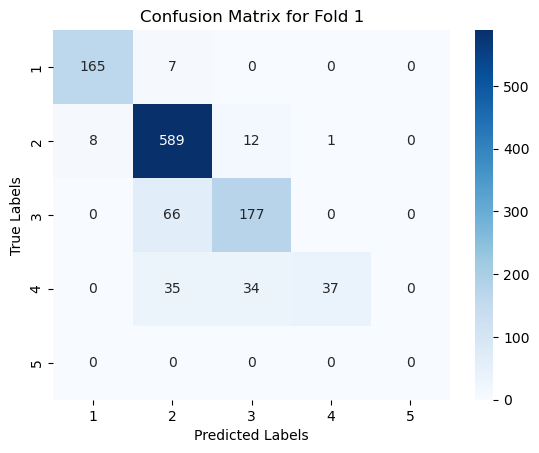

Fold 2 - Training label distribution: [   0  688 2440  972  424]
Fold 2 - Test label distribution: [  0 172 610 243 106]
Fold 2 Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92       172
           2       0.82      0.96      0.88       610
           3       0.79      0.65      0.72       243
           4       0.98      0.42      0.59       106

    accuracy                           0.84      1131
   macro avg       0.88      0.74      0.78      1131
weighted avg       0.84      0.84      0.83      1131



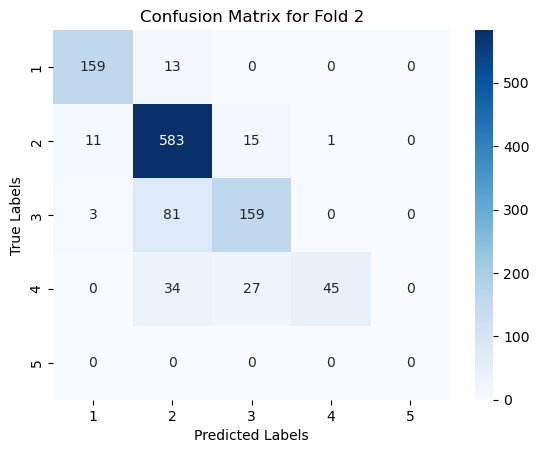

Fold 3 - Training label distribution: [   0  688 2440  972  424]
Fold 3 - Test label distribution: [  0 172 610 243 106]
Fold 3 Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.95      0.92       172
           2       0.83      0.96      0.89       610
           3       0.85      0.70      0.77       243
           4       0.98      0.39      0.55       106

    accuracy                           0.85      1131
   macro avg       0.89      0.75      0.78      1131
weighted avg       0.86      0.85      0.84      1131



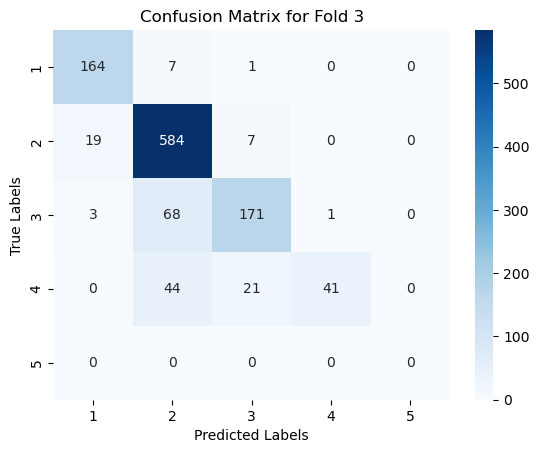

Fold 4 - Training label distribution: [   0  688 2440  972  424]
Fold 4 - Test label distribution: [  0 172 610 243 106]
Fold 4 Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.95      0.90       172
           2       0.82      0.95      0.88       610
           3       0.82      0.65      0.72       243
           4       1.00      0.37      0.54       106

    accuracy                           0.83      1131
   macro avg       0.87      0.73      0.76      1131
weighted avg       0.84      0.83      0.82      1131



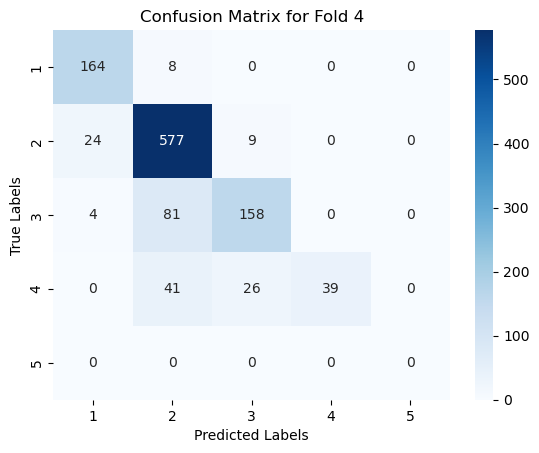

Fold 5 - Training label distribution: [   0  688 2440  972  424]
Fold 5 - Test label distribution: [  0 172 610 243 106]
Fold 5 Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.96      0.93       172
           2       0.83      0.95      0.89       610
           3       0.79      0.68      0.73       243
           4       0.98      0.38      0.54       106

    accuracy                           0.84      1131
   macro avg       0.87      0.74      0.77      1131
weighted avg       0.85      0.84      0.83      1131



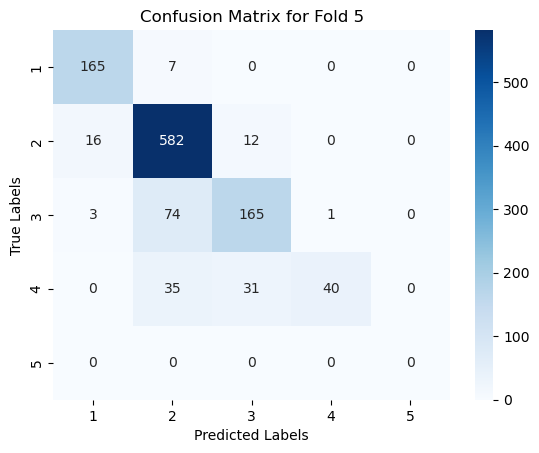

Cross-validation accuracy: [0.8558797524314765, 0.8364279398762158, 0.8488063660477454, 0.8293545534924845, 0.8417329796640142]
Mean accuracy: 0.8424403183023873
Model saved as 'random_forest_model.pkl'


In [63]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    return dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型，并移除类别 0
    labels = labels.astype(int)
    unique_labels = np.unique(labels)
    print(f"Unique labels after processing: {unique_labels}")  # 打印唯一标签，确保没有类别 0

    if 0 in unique_labels:
        raise ValueError("Label 0 is still present in the dataset. Please check the label processing.")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 2})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(features, labels)):
        train_features, test_features = features[train_idx], features[test_idx]
        train_labels, test_labels = labels[train_idx], labels[test_idx]

        # 打印训练集和测试集的标签分布
        print(f"Fold {fold + 1} - Training label distribution: {np.bincount(train_labels)}")
        print(f"Fold {fold + 1} - Test label distribution: {np.bincount(test_labels)}")

        clf.fit(train_features, train_labels)
        test_predictions = clf.predict(test_features)

        print(f"Fold {fold + 1} Classification Report:")
        print(classification_report(test_labels, test_predictions))

        # 确保混淆矩阵中的标签为 [1, 2, 3, 4, 5]
        conf_matrix = confusion_matrix(test_labels, test_predictions, labels=[1, 2, 3, 4, 5])
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for Fold {fold + 1}')
        plt.show()

        scores.append(clf.score(test_features, test_labels))

    print(f"Cross-validation accuracy: {scores}")
    print(f"Mean accuracy: {np.mean(scores)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()

Loaded labels from file:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail1_augmented: (array([1, 2, 3, 4]), array([175, 155,  45,  35], dtype=int64))
Loaded labels from file:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail2_augmented: (array([1, 2, 3, 4]), array([290, 155, 105,  30], dtype=int64))
Loaded labels from file:
label
5    149
3     84
2     66
1     49
4     42
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail3_augmented: (array([2, 3, 4]), array([55, 70, 35], dtype=int64))
Loaded labels from file:
label
5    416
2    156
1    152
4     60
3     24
Name: count, dtype: int64
Labels dictionary contai

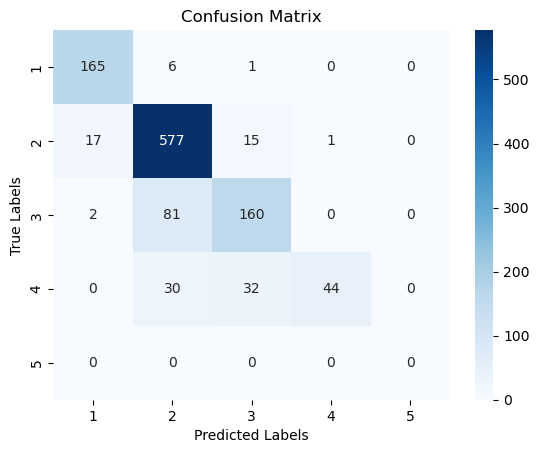

Model accuracy: 0.8364279398762158
Model saved as 'random_forest_model.pkl'


In [69]:
import numpy as np
import pandas as pd
import os
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# HOG 特征计算
def compute_hog_features(data, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    n = len(data)
    side = int(np.ceil(np.sqrt(n)))
    padded_data = np.zeros((side * side,))
    padded_data[:n] = data

    image = padded_data.reshape((side, side))
    return hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels from file:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    labels_dict = dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))
    print(f"Labels dictionary contains labels: {set(labels_dict.values())}")  # 打印标签字典中的唯一标签
    return labels_dict


def extract_features_from_file(file_path):
    try:
        data = pd.read_csv(file_path)
        if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
            print(f"Required columns missing in file {file_path}, skipping.")
            return None

        features = []
        fixed_length = 1024

        for col in ['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']:
            strain_data = data[col].to_numpy()

            if len(strain_data) < fixed_length:
                padded_data = np.zeros(fixed_length)
                padded_data[:len(strain_data)] = strain_data
            else:
                padded_data = strain_data[:fixed_length]

            hog_features = compute_hog_features(padded_data)
            features.append(hog_features)

        return np.hstack(features)

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None


def extract_features(folder_path, labels_dict):
    features, labels = [], []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            feature_vector = extract_features_from_file(file_path)
            if feature_vector is not None:
                features.append(feature_vector)
                labels.append(label)

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    print(f"Extracted labels from folder {folder_path}: {np.unique(labels, return_counts=True)}")  # 打印提取的标签及其数量，确保所有标签都被正确提取
    return np.array(features), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型，并移除类别 0
    labels = labels.astype(int)
    unique_labels = np.unique(labels)
    print(f"Unique labels after processing: {unique_labels}")  # 打印唯一标签，确保没有类别 0

    if 0 in unique_labels:
        raise ValueError("Label 0 is still present in the dataset. Please check the label processing.")

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 分割数据集，确保每个类别在训练和测试集中都有足够的样本
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # 打印训练集和测试集的标签分布
    print(f"Training label distribution: {np.bincount(train_labels)}")
    print(f"Test label distribution: {np.bincount(test_labels)}")

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 5})
    clf.fit(train_features, train_labels)
    test_predictions = clf.predict(test_features)

    print("Classification Report:")
    print(classification_report(test_labels, test_predictions))

    # 确保混淆矩阵中的标签为 [1, 2, 3, 4, 5]
    conf_matrix = confusion_matrix(test_labels, test_predictions, labels=[1, 2, 3, 4, 5])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    print(f"Model accuracy: {clf.score(test_features, test_labels)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.append(features)
            all_labels.append(labels)

    all_features = np.vstack(all_features)
    all_labels = np.hstack(all_labels)

    print(f"All extracted labels before training: {np.unique(all_labels, return_counts=True)}")  # 打印所有提取的标签及其数量，确保完整性
    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()

In [ ]:
适合你的数据的特征提取方法
如果你的目标是分析 XYZ 坐标、主应变、次应变和减薄数据，以下方法可能更合适：
1. 点云分析方法
•	PCA（主成分分析）：可以提取点云的主要方向和几何特征。
•	Curvature Analysis（曲率分析）：分析点云表面的曲率变化，以捕捉局部几何特性。
•	法向量计算：在点云中计算每个点的法向量以描述表面特性。
2. 基于应变和减薄分布的特征提取
•	应变梯度计算：类似于 HOG，你可以计算主应变 E1E_1E1 和次应变 E2E_2E2 的梯度，分析应变的变化趋势。
•	分区统计：将数据分成小区域，对每个区域计算特征统计量（如均值、标准差、最大值等）。
•	应变分布直方图：统计 E1E_1E1 和 E2E_2E2 的分布特征，类似 HOG 的直方图方法。
3. 减薄分析
•	通过 ThinningThinningThinning 数据的空间分布，提取其变化趋势。例如：
o	计算减薄率的梯度。
o	分析减薄的局部极值点或均匀性。



Label distribution before loading: []
Loaded labels from file:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Label distribution before extracting: []
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail1_augmented: (array([1, 2, 3, 4, 5]), array([210, 186,  54,  42, 231], dtype=int64))
Label distribution before extending: []
Label distribution after extending: [  0 210 186  54  42 231]
Label distribution before loading: [  0 210 186  54  42 231]
Loaded labels from file:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Label distribution before extracting: [  0 210 186  54  42 231]
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail2_augmented: (array([1, 2, 3, 4, 5]), array([348, 186, 126,  36, 296], dtype=int64))
Label distribution before extending: [  0 210 186  54  42 231]
Label distribution after 

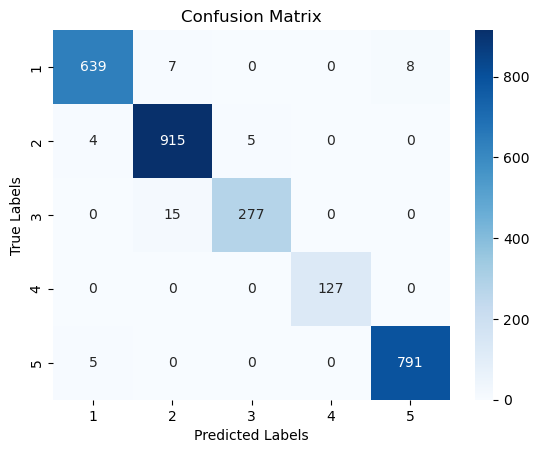

Model accuracy: 0.9842463301109917
Model saved as 'random_forest_model.pkl'


In [95]:
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels from file:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    labels_dict = dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))
    print(f"Labels dictionary contains labels: {set(labels_dict.values())}")  # 打印标签字典中的唯一标签
    return labels_dict


# 特征提取函数
def extract_features(folder_path, labels_dict):
    features, labels = [], []
    missing_labels = []
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                continue

            file_path = os.path.join(folder_path, file_name)
            try:
                data = pd.read_csv(file_path)
                if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
                    print(f"Required columns missing in file {file_path}, skipping.")
                    missing_labels.append((file_name, label))
                    continue

                # 特征提取：PCA、应变梯度、分区统计等
                feature_vector = []

                # 1. PCA 特征提取 (主成分分析)
                pca = PCA(n_components=3)
                pca_features = pca.fit_transform(data[['X', 'Y', 'Z']])
                feature_vector.extend(np.mean(pca_features, axis=0))  # 使用 PCA 主成分的均值作为特征

                # 2. 应变梯度计算 (计算 E1 和 E2 的梯度统计量)
                e1_gradient = np.gradient(data['E1'])
                e2_gradient = np.gradient(data['E2'])
                feature_vector.extend([np.mean(e1_gradient), np.std(e1_gradient), np.max(e1_gradient), np.min(e1_gradient)])
                feature_vector.extend([np.mean(e2_gradient), np.std(e2_gradient), np.max(e2_gradient), np.min(e2_gradient)])

                # 3. 分区统计 (对 E1, E2, Thinning 进行分区统计)
                num_partitions = 4
                partition_size = len(data) // num_partitions
                for col in ['E1', 'E2', 'Thinning']:
                    for i in range(num_partitions):
                        partition_data = data[col][i * partition_size:(i + 1) * partition_size]
                        feature_vector.extend([partition_data.mean(), partition_data.std(), partition_data.max(), partition_data.min()])

                # 4. 减薄率的梯度计算和局部特征分析
                thinning_gradient = np.gradient(data['Thinning'])
                feature_vector.extend([np.mean(thinning_gradient), np.std(thinning_gradient), np.max(thinning_gradient), np.min(thinning_gradient)])
                thinning_max = data['Thinning'].max()
                thinning_min = data['Thinning'].min()
                feature_vector.extend([thinning_max, thinning_min])

                features.append(feature_vector)
                labels.append(label)
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")
                missing_labels.append((file_name, label))

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    print(f"Extracted labels from folder {folder_path}: {np.unique(labels, return_counts=True)}")  # 打印提取的标签及其数量，确保所有标签都被正确提取
    if missing_labels:
        print(f"Missing labels due to extraction failure: {missing_labels}")  # 打印因特征提取失败而丢失的标签及其文件名

    return np.array(features, dtype=object), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型，并移除类别 0
    labels = labels.astype(int)
    unique_labels = np.unique(labels)
    print(f"Unique labels after processing: {unique_labels}")  # 打印唯一标签，确保没有类别 0

    if 0 in unique_labels:
        raise ValueError("Label 0 is still present in the dataset. Please check the label processing.")

    # 标准化特征
    scaler = StandardScaler()
    features = scaler.fit_transform(list(features))

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 分割数据集，确保每个类别在训练和测试集中都有足够的样本
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # 打印训练集和测试集的标签分布
    print(f"Training label distribution: {np.bincount(train_labels)}")
    print(f"Test label distribution: {np.bincount(test_labels)}")

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 5})
    clf.fit(train_features, train_labels)
    test_predictions = clf.predict(test_features)

    print("Classification Report:")
    print(classification_report(test_labels, test_predictions))

    # 确保混淆矩阵中的标签为 [1, 2, 3, 4, 5]
    conf_matrix = confusion_matrix(test_labels, test_predictions, labels=[1, 2, 3, 4, 5])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    print(f"Model accuracy: {clf.score(test_features, test_labels)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")
            print(f"Label distribution before loading: {np.bincount(all_labels)}")
            labels_dict = load_expert_labels(labels_file_path)
            print(f"Label distribution before extracting: {np.bincount(all_labels)}")
            features, labels = extract_features(augmented_folder, labels_dict)
            print(f"Label distribution before extending: {np.bincount(all_labels)}")
            all_features.extend(features)
            all_labels.extend(labels)
            print(f"Label distribution after extending: {np.bincount(all_labels)}")
    print(f"Label distribution before arrayng: {np.bincount(all_labels)}")
    all_features = np.array(all_features, dtype=object)
    all_labels = np.array(all_labels)
    
    print(f"All extracted labels before training: {np.unique(all_labels, return_counts=True)}")  # 打印所有提取的标签及其数量，确保完整性
    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Loaded labels from file:
label
5    231
1    210
2    186
3     54
4     42
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail1_augmented: (array([1, 2, 3, 4]), array([175, 155,  45,  35], dtype=int64))
Loaded labels from file:
label
1    348
5    296
2    186
3    126
4     36
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail2_augmented: (array([1, 2, 3, 4]), array([290, 155, 105,  30], dtype=int64))
Loaded labels from file:
label
5    149
3     84
2     66
1     49
4     42
Name: count, dtype: int64
Labels dictionary contains labels: {1, 2, 3, 4, 5}
Extracted labels from folder C:\Material-5083\Geometry-20mm\trail3_augmented: (array([2, 3, 4]), array([55, 70, 35], dtype=int64))
Loaded labels from file:
label
5    416
2    156
1    152
4     60
3     24
Name: count, dtype: int64
Labels dictionary contai

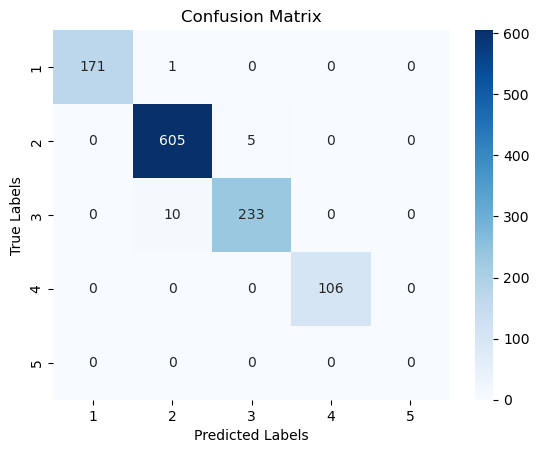

Model accuracy: 0.9858532272325375
Model saved as 'random_forest_model.pkl'


In [79]:
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5，确保所有标签都是 1-5
    print("Loaded labels from file:")
    print(expert_labels_df['label'].value_counts())  # 打印标签的分布情况，确保所有标签都被正确加载
    labels_dict = dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))
    print(f"Labels dictionary contains labels: {set(labels_dict.values())}")  # 打印标签字典中的唯一标签
    return labels_dict


# 特征提取函数
def extract_features(folder_path, labels_dict):
    features, labels = [], []
    missing_labels = []
    skipped_files = []  # 用于记录被跳过的文件
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None:
                print(f"Label not found for {file_name}, skipping.")
                skipped_files.append((file_name, 'Label not found'))
                continue

            file_path = os.path.join(folder_path, file_name)
            try:
                data = pd.read_csv(file_path)
                if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
                    print(f"Required columns missing in file {file_path}, skipping.")
                    missing_labels.append((file_name, label))
                    skipped_files.append((file_name, 'Required columns missing'))
                    continue

                # 特征提取：PCA、应变梯度、分区统计等
                feature_vector = []

                # 1. PCA 特征提取 (主成分分析)
                pca = PCA(n_components=3)
                pca_features = pca.fit_transform(data[['X', 'Y', 'Z']])
                feature_vector.extend(np.mean(pca_features, axis=0))  # 使用 PCA 主成分的均值作为特征

                # 2. 应变梯度计算 (计算 E1 和 E2 的梯度统计量)
                e1_gradient = np.gradient(data['E1'])
                e2_gradient = np.gradient(data['E2'])
                feature_vector.extend([np.mean(e1_gradient), np.std(e1_gradient), np.max(e1_gradient), np.min(e1_gradient)])
                feature_vector.extend([np.mean(e2_gradient), np.std(e2_gradient), np.max(e2_gradient), np.min(e2_gradient)])

                # 3. 分区统计 (对 E1, E2, Thinning 进行分区统计)
                num_partitions = 4
                partition_size = len(data) // num_partitions
                for col in ['E1', 'E2', 'Thinning']:
                    for i in range(num_partitions):
                        partition_data = data[col][i * partition_size:(i + 1) * partition_size]
                        feature_vector.extend([partition_data.mean(), partition_data.std(), partition_data.max(), partition_data.min()])

                # 4. 减薄率的梯度计算和局部特征分析
                thinning_gradient = np.gradient(data['Thinning'])
                feature_vector.extend([np.mean(thinning_gradient), np.std(thinning_gradient), np.max(thinning_gradient), np.min(thinning_gradient)])
                thinning_max = data['Thinning'].max()
                thinning_min = data['Thinning'].min()
                feature_vector.extend([thinning_max, thinning_min])

                features.append(feature_vector)
                labels.append(label)
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")
                missing_labels.append((file_name, label))
                skipped_files.append((file_name, f"Error: {e}"))

    if not features:
        raise ValueError(f"No valid features extracted from folder: {folder_path}. Please check your data.")

    print(f"Extracted labels from folder {folder_path}: {np.unique(labels, return_counts=True)}")  # 打印提取的标签及其数量，确保所有标签都被正确提取
    if missing_labels:
        print(f"Missing labels due to extraction failure: {missing_labels}")  # 打印因特征提取失败而丢失的标签及其文件名
    if skipped_files:
        print(f"Skipped files: {skipped_files}")  # 打印被跳过的文件及其原因

    return np.array(features, dtype=object), np.array(labels)


# 模型训练和评估
def train_and_evaluate_model(features, labels):
    # 打印标签分布，确保没有类别被遗漏
    print(f"Label distribution before training: {np.bincount(labels)}")

    # 确保标签为整数类型，并移除类别 0
    labels = labels.astype(int)
    unique_labels = np.unique(labels)
    print(f"Unique labels after processing: {unique_labels}")  # 打印唯一标签，确保没有类别 0

    if 0 in unique_labels:
        raise ValueError("Label 0 is still present in the dataset. Please check the label processing.")

    # 标准化特征
    scaler = StandardScaler()
    features = scaler.fit_transform(list(features))

    # 进行 PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 分割数据集，确保每个类别在训练和测试集中都有足够的样本
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # 打印训练集和测试集的标签分布
    print(f"Training label distribution: {np.bincount(train_labels)}")
    print(f"Test label distribution: {np.bincount(test_labels)}")

    # 调整 RandomForestClassifier 的参数
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight={1: 1, 2: 1, 3: 1, 4: 5, 5: 5})
    clf.fit(train_features, train_labels)
    test_predictions = clf.predict(test_features)

    print("Classification Report:")
    print(classification_report(test_labels, test_predictions))

    # 确保混淆矩阵中的标签为 [1, 2, 3, 4, 5]
    conf_matrix = confusion_matrix(test_labels, test_predictions, labels=[1, 2, 3, 4, 5])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    print(f"Model accuracy: {clf.score(test_features, test_labels)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")


# 主程序
def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features, all_labels = [], []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)
            all_features.extend(features)
            all_labels.extend(labels)

    all_features = np.array(all_features, dtype=object)
    all_labels = np.array(all_labels)

    print(f"All extracted labels before training: {np.unique(all_labels, return_counts=True)}")  # 打印所有提取的标签及其数量，确保完整性
    train_and_evaluate_model(all_features, all_labels)


if __name__ == "__main__":
    main()


Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Skipped files: []
Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.98      0.98       654
           2       0.98      0.99      0.98       924
           3       0.98      0.95      0.97       292
           4       1.00      1.00      1.00       127
           5       0.99      0.99      0.99       796

    accuracy                           0.99      2793
   macro avg       0.99      0.98      0.99      2793
weighted avg       0.99      0.99      0.99      2793



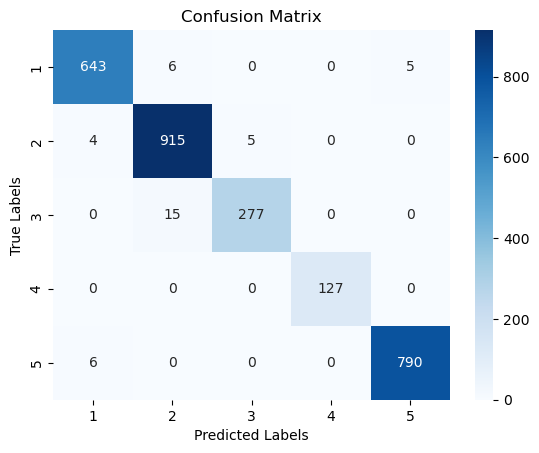

Model accuracy: 0.9853204439670605
Model saved as 'random_forest_model.pkl'


In [99]:
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# 加载标注文件
def load_expert_labels(labels_file_path):
    expert_labels_df = pd.read_excel(labels_file_path)
    expert_labels_df['label'] = expert_labels_df['label'].replace(0, 5)  # 将标签 0 修改为 5
    labels_dict = dict(zip(expert_labels_df['filename'].str.replace('.csv', ''), expert_labels_df['label']))
    return labels_dict

# 特征提取函数
def extract_features(folder_path, labels_dict):
    features, labels = [], []
    skipped_files = []  # 用于记录被跳过的文件及原因
    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            base_name = os.path.splitext(file_name)[0]
            label = labels_dict.get(base_name)

            if label is None or label not in [1, 2, 3, 4, 5]:
                skipped_files.append((file_name, 'Invalid or missing label'))
                continue

            file_path = os.path.join(folder_path, file_name)
            try:
                data = pd.read_csv(file_path)
                if not set(['E1', 'E2', 'Thinning', 'X', 'Y', 'Z']).issubset(data.columns):
                    skipped_files.append((file_name, 'Required columns missing'))
                    continue

                # 特征提取
                feature_vector = []

                # PCA 特征提取
                pca = PCA(n_components=3)
                pca_features = pca.fit_transform(data[['X', 'Y', 'Z']])
                feature_vector.extend(np.mean(pca_features, axis=0))

                # 应变梯度
                for col in ['E1', 'E2']:
                    gradient = np.gradient(data[col])
                    feature_vector.extend([np.mean(gradient), np.std(gradient), np.max(gradient), np.min(gradient)])

                # 分区统计
                num_partitions = 4
                partition_size = len(data) // num_partitions
                for col in ['E1', 'E2', 'Thinning']:
                    for i in range(num_partitions):
                        partition_data = data[col][i * partition_size:(i + 1) * partition_size]
                        feature_vector.extend([partition_data.mean(), partition_data.std(), partition_data.max(), partition_data.min()])

                # 减薄率
                thinning_gradient = np.gradient(data['Thinning'])
                feature_vector.extend([np.mean(thinning_gradient), np.std(thinning_gradient), np.max(thinning_gradient), np.min(thinning_gradient)])
                feature_vector.extend([data['Thinning'].max(), data['Thinning'].min()])

                features.append(feature_vector)
                labels.append(label)
            except Exception as e:
                skipped_files.append((file_name, f"Error: {e}"))

    print(f"Skipped files: {skipped_files}")  # 打印被跳过的文件及原因
    return np.array(features, dtype=object), np.array(labels)

# 模型训练和评估
def train_and_evaluate_model(features, labels):
    if features.shape[0] == 0 or labels.shape[0] == 0:
        raise ValueError("No valid data available for training.")

    labels = labels.astype(int)

    # 标准化特征
    scaler = StandardScaler()
    features = scaler.fit_transform(features)

    # PCA 降维
    pca = PCA(n_components=min(50, features.shape[1]))
    features = pca.fit_transform(features)

    # 分割数据集
    train_features, test_features, train_labels, test_labels = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # 训练模型
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
    clf.fit(train_features, train_labels)
    test_predictions = clf.predict(test_features)

    print("Classification Report:")
    print(classification_report(test_labels, test_predictions, labels=[1, 2, 3, 4, 5]))

    # 混淆矩阵
    conf_matrix = confusion_matrix(test_labels, test_predictions, labels=[1, 2, 3, 4, 5])
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    print(f"Model accuracy: {clf.score(test_features, test_labels)}")

    # 保存模型
    joblib.dump(clf, 'random_forest_model.pkl')
    print("Model saved as 'random_forest_model.pkl'")

def main():
    base_path = r'C:\Material-5083'

    geometry_folders = ['20', '60', '100', '120', '180']
    trail_names = ['trail1', 'trail2', 'trail3']

    all_features = []
    all_labels = []

    for geometry_folder in geometry_folders:
        for trail_name in trail_names:
            augmented_folder = os.path.join(base_path, f"Geometry-{geometry_folder}mm", f"{trail_name}_augmented")
            labels_file_path = os.path.join(augmented_folder, "augmented_labels.xlsx")

            labels_dict = load_expert_labels(labels_file_path)
            features, labels = extract_features(augmented_folder, labels_dict)

            if len(features) == 0 or len(labels) == 0:
                print(f"No valid features or labels extracted for {augmented_folder}. Skipping.")
                continue

            all_features.extend(features)
            all_labels.extend(labels)

    all_features = np.array(all_features, dtype=float)
    all_labels = np.array(all_labels, dtype=int)

    if all_features.ndim == 1:
        all_features = all_features.reshape(-1, 1)

    if len(all_features) == 0 or len(all_labels) == 0:
        print("No valid data available. Exiting.")
        return

    train_and_evaluate_model(all_features, all_labels)

if __name__ == "__main__":
    main()
